# Swin Transformer pré-treinado — Mamografia Normal x Anormal (Mini-DDSM)

**Estrutura:**

*Config -> Imports -> Dataset -> Pré-processamento -> Augmentation -> Modelo -> Treinamento -> Validação -> Métricas -> Gráficos -> Resultados.*

## 1. Configuração

In [1]:
# Todos os parâmetros ajustáveis do experimento, num único lugar.

SEED = 42

# --- Fonte de dados ---
# "mini_mias": ~322 imagens — usar para o sanity check rápido do pipeline.
# "mini_ddsm": ~10.000 imagens — usar para o treino completo, só depois do
#              sanity check no mini_mias ter passado sem erros.
DATASET_SOURCE = "mini_ddsm"

# --- Dados ---
IMG_SIZE = 224
N_FOLDS = 3            # 3 para testes/sanity check; suba para 5 no treino final reportado
DATASET_DIR = "dataset_cv"    # pasta final: dataset_cv/normal, dataset_cv/anormal
RAW_DIR = "dataset_raw"       # pasta temporária com as imagens originais baixadas

# --- Treino ---
NUM_EPOCHS = 5         # sanity check: 1-2 épocas. Suba para 15-20 no treino completo
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
DROP_RATE = 0.1
DROP_PATH_RATE = 0.2
FREEZE_STAGES = 2   # dos 4 stages do Swin-Tiny; 0 = fine-tuning completo
PACIENCIA = 5       # early stopping: nº de épocas sem melhora de AUC de validação

# --- Infraestrutura ---
CHECKPOINT_DIR = "checkpoints"
NUM_WORKERS = 2         # paraleliza o carregamento/augmentation fora do processo principal
USE_AMP = True          # Mixed Precision (float16) — só tem efeito com GPU CUDA disponível


## 2. Imports

In [2]:
!pip install timm kaggle PyPDF2 -q

import os
import re
import random
import shutil
import zipfile
import getpass
import time

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import timm

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from tqdm.auto import tqdm


def configurar_semente(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


configurar_semente()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cpu":
    print("ATENÇÃO: sem GPU nesta sessão. Ambiente de execução -> Alterar tipo -> GPU (T4).")

# AMP (mixed precision) só faz sentido com GPU CUDA; em CPU, é ignorado.
USE_AMP = USE_AMP and device.type == "cuda"
print(f"Mixed Precision (AMP): {'ativado' if USE_AMP else 'desativado'}")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.7 MB/s eta 0:00:00
Dispositivo: cuda
Mixed Precision (AMP): ativado


## 3. Dataset

Fonte: Mini-DDSM (Kaggle `cheddad/miniddsm2`, versão JPEG — a versão PNG tem 47GB e não é necessária).
Classes finais: `normal` (casos Normal) e `anormal` (Benign + Cancer agrupados).
O agrupamento por paciente usa a própria pasta que contém a imagem (cada caso tem sua pasta no Mini-DDSM) — evita vazamento entre treino e validação sem depender de regex frágil no nome do arquivo.

**Pré-requisito**: um token de API do Kaggle (string `KGAT_...`, gerado em kaggle.com -> Settings -> API Tokens). A célula pede para colar; nada fica salvo em texto no notebook.

In [3]:
def _configurar_token_kaggle():
    pasta_cfg = os.path.expanduser("~/.kaggle")
    os.makedirs(pasta_cfg, exist_ok=True)
    caminho = os.path.join(pasta_cfg, "access_token")
    if not os.path.exists(caminho):
        print("Cole o token do Kaggle (kaggle.com -> Settings -> API Tokens -> Generate New Token):")
        token = getpass.getpass("Token: ").strip()
        with open(caminho, "w") as f:
            f.write(token)
    os.chmod(caminho, 0o600)
    with open(caminho) as f:
        os.environ["KAGGLE_API_TOKEN"] = f.read().strip()


def _baixar_e_extrair_miniddsm():
    zip_local = "miniddsm2.zip"
    ja_extraido = os.path.isdir(RAW_DIR) and os.listdir(RAW_DIR)

    if not os.path.exists(zip_local) and not ja_extraido:
        print("Baixando Mini-DDSM do Kaggle (pode levar alguns minutos)...")
        ret = os.system("kaggle datasets download -d cheddad/miniddsm2 -o -p .")
        candidatos = [f for f in os.listdir(".") if f.startswith("miniddsm2") and f.endswith(".zip")]
        if ret != 0 or not candidatos:
            raise RuntimeError(
                "Falha ao baixar via Kaggle API. Confira o token e se você já "
                "aceitou os termos do dataset no site (botão Download, uma vez)."
            )
        zip_local = candidatos[0]

    if not ja_extraido:
        os.makedirs(RAW_DIR, exist_ok=True)
        print("Extraindo apenas os arquivos JPEG (ignora a versão PNG de 47GB)...")
        with zipfile.ZipFile(zip_local) as z:
            membros = [m for m in z.namelist() if "JPEG" in m.upper() and not m.endswith("/")]
            for m in membros:
                z.extract(m, RAW_DIR)

    if os.path.exists(zip_local):
        os.remove(zip_local)  # libera espaço: não precisamos mais do zip


def _classificar_por_caminho_ddsm(caminho):
    partes = caminho.lower().split(os.sep)
    for p in partes:
        if "cancer" in p or "malign" in p or "benign" in p:
            return "anormal"
        if "normal" in p or "healthy" in p:
            return "normal"
    return None


def preparar_dataset_mini_ddsm():
    """Baixa (se preciso) e organiza o Mini-DDSM em dataset_cv/{normal,anormal}.
    ~10.000 imagens — dataset de treino completo (Fase 3)."""
    _configurar_token_kaggle()
    _baixar_e_extrair_miniddsm()

    imagens = []
    for raiz, _, arquivos in os.walk(RAW_DIR):
        for a in arquivos:
            if a.lower().endswith((".jpg", ".jpeg", ".png")):
                imagens.append(os.path.join(raiz, a))

    registros = []  # (caminho, classe, pasta_paciente)
    for caminho in imagens:
        classe = _classificar_por_caminho_ddsm(caminho)
        if classe is not None:
            registros.append((caminho, classe, os.path.dirname(caminho)))

    if not registros:
        raise RuntimeError(
            "Nenhuma imagem classificada — a estrutura de pastas do dataset "
            "baixado não bateu com o esperado. Primeiros caminhos encontrados:\n"
            + "\n".join(imagens[:10])
        )

    os.makedirs(f"{DATASET_DIR}/normal", exist_ok=True)
    os.makedirs(f"{DATASET_DIR}/anormal", exist_ok=True)
    mapa_pid = {p: i for i, p in enumerate(sorted({r[2] for r in registros}))}

    for i, (caminho, classe, pasta) in enumerate(tqdm(registros, desc="Processando imagens")):
        img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = recortar_tecido(img)   # definidos na célula de pré-processamento
        img = aplicar_clahe(img)     # CLAHE pré-calculado uma única vez aqui
        nome = f"pid{mapa_pid[pasta]:05d}_img{i:06d}.jpg"
        cv2.imwrite(os.path.join(DATASET_DIR, classe, nome), img, [cv2.IMWRITE_JPEG_QUALITY, 95])

    shutil.rmtree(RAW_DIR, ignore_errors=True)  # libera espaço

    n_normal = sum(1 for _, c, _ in registros if c == "normal")
    n_anormal = len(registros) - n_normal
    print(f"'{DATASET_DIR}/' pronto: {len(registros)} imagens "
          f"({n_normal} normal, {n_anormal} anormal), {len(mapa_pid)} pacientes.")


# ------------------------------------------------------------------
# Mini-MIAS (~322 imagens) — só para o sanity check rápido do pipeline
# ------------------------------------------------------------------
_MIAS_FONTES = [
    ("https://codeload.github.com/changocoder/databases/zip/refs/heads/master", "mias_github.zip"),
    ("http://peipa.essex.ac.uk/pix/mias/all-mias.tar.gz", "mias_peipa.tar.gz"),
]
_MIAS_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; ColabDownloader/1.0)"}


def _mias_pasta_tem_dados(pasta):
    if not os.path.isdir(pasta):
        return False
    return any(a.endswith(".pgm") for _, _, arqs in os.walk(pasta) for a in arqs)


def _mias_baixar_e_extrair():
    import requests
    if _mias_pasta_tem_dados(RAW_DIR):
        return
    os.makedirs(RAW_DIR, exist_ok=True)
    for url, nome_arquivo in _MIAS_FONTES:
        try:
            print(f"Tentando baixar mini-MIAS de: {url}")
            with requests.get(url, headers=_MIAS_HEADERS, stream=True, timeout=120) as r:
                r.raise_for_status()
                with open(nome_arquivo, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            if zipfile.is_zipfile(nome_arquivo):
                with zipfile.ZipFile(nome_arquivo) as z:
                    z.extractall(RAW_DIR)
            else:
                import tarfile
                with tarfile.open(nome_arquivo, "r:gz") as tar:
                    tar.extractall(RAW_DIR)
            os.remove(nome_arquivo)
            if _mias_pasta_tem_dados(RAW_DIR):
                return
        except Exception as e:
            print(f"Falhou ({url}): {e}")
    raise RuntimeError("Não foi possível baixar o mini-MIAS de nenhum mirror.")


def _mias_ler_classes(pasta_pgms):
    """Lê o README/Info do mini-MIAS e devolve {nome_arquivo: 'NORM'|outra_classe}."""
    candidatos = []
    for raiz, _, arquivos in os.walk(pasta_pgms):
        for a in arquivos:
            if "readme" in a.lower() or "info" in a.lower():
                candidatos.append(os.path.join(raiz, a))
    if not candidatos:
        raise FileNotFoundError("Não encontrei o arquivo de metadados (README/Info) do mini-MIAS.")

    caminho_info = candidatos[0]
    if caminho_info.lower().endswith(".pdf"):
        from PyPDF2 import PdfReader
        texto = "\n".join(p.extract_text() or "" for p in PdfReader(caminho_info).pages)
    else:
        with open(caminho_info, "r", errors="ignore") as f:
            texto = f.read()

    mapa_classes = {}
    for linha in texto.split("\n"):
        linha = linha.strip()
        if linha.startswith("mdb"):
            partes = linha.split()
            if len(partes) >= 3:
                mapa_classes[partes[0] + ".pgm"] = partes[2]
    return mapa_classes


def preparar_dataset_mini_mias():
    """Baixa e organiza o mini-MIAS em dataset_cv/{normal,anormal}.
    ~322 imagens — usado só para o sanity check (Fase 1)."""
    _mias_baixar_e_extrair()

    pasta_pgms = RAW_DIR
    for raiz, _, arquivos in os.walk(RAW_DIR):
        if any(a.endswith(".pgm") for a in arquivos):
            pasta_pgms = raiz
            break

    mapa_classes = _mias_ler_classes(RAW_DIR)
    imagens = sorted(f for f in os.listdir(pasta_pgms) if f.endswith(".pgm"))

    os.makedirs(f"{DATASET_DIR}/normal", exist_ok=True)
    os.makedirs(f"{DATASET_DIR}/anormal", exist_ok=True)

    n_normal, n_anormal = 0, 0
    for nome in tqdm(imagens, desc="Processando imagens"):
        classe_raw = mapa_classes.get(nome)
        if classe_raw is None:
            continue
        classe = "normal" if classe_raw == "NORM" else "anormal"

        img = cv2.imread(os.path.join(pasta_pgms, nome), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = recortar_tecido(img)
        img = aplicar_clahe(img)

        # mdb001/mdb002 = mesmo paciente (mama esquerda/direita), par consecutivo
        numero = int(re.search(r"mdb(\d+)", nome).group(1))
        pid = (numero - 1) // 2
        nome_saida = f"pid{pid:05d}_img{numero:06d}.jpg"
        cv2.imwrite(os.path.join(DATASET_DIR, classe, nome_saida), img, [cv2.IMWRITE_JPEG_QUALITY, 95])

        n_normal += classe == "normal"
        n_anormal += classe == "anormal"

    shutil.rmtree(RAW_DIR, ignore_errors=True)
    print(f"'{DATASET_DIR}/' pronto: {n_normal + n_anormal} imagens "
          f"({n_normal} normal, {n_anormal} anormal).")


def preparar_dataset():
    """Dispatcher: baixa e organiza o dataset escolhido em DATASET_SOURCE."""
    if os.path.isdir(DATASET_DIR) and os.listdir(DATASET_DIR):
        print(f"'{DATASET_DIR}' já existe, pulando preparação. "
              f"Se quiser trocar de dataset, apague essa pasta antes.")
        return

    if DATASET_SOURCE == "mini_mias":
        preparar_dataset_mini_mias()
    elif DATASET_SOURCE == "mini_ddsm":
        preparar_dataset_mini_ddsm()
    else:
        raise ValueError(f"DATASET_SOURCE inválido: '{DATASET_SOURCE}' (use 'mini_mias' ou 'mini_ddsm').")


## 4. Pré-processamento

In [4]:
def recortar_tecido(img):
    """Remove a borda preta ao redor da mama (crop pelo maior contorno)."""
    _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        c = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        recorte = img[y:y+h, x:x+w]
        if recorte.shape[0] >= 64 and recorte.shape[1] >= 64:
            return recorte
    return img


_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def aplicar_clahe(img_gray):
    """Realce de contraste local — ajuda a destacar tecido denso e microcalcificações.

    Aplicado UMA VEZ aqui, ao preparar o dataset (não a cada época dentro do
    transform). Antes, o CLAHE rodava dentro de train_transform/test_transform
    e era recalculado para cada imagem em cada época — desperdício de CPU
    repetido, já que o resultado é sempre o mesmo para a mesma imagem de entrada.
    """
    img_norm = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return _CLAHE.apply(img_norm)


preparar_dataset()


Cole o token do Kaggle (kaggle.com -> Settings -> API Tokens -> Generate New Token):
Token: ··········
Baixando Mini-DDSM do Kaggle (pode levar alguns minutos)...
Extraindo apenas os arquivos JPEG (ignora a versão PNG de 47GB)...


Processando imagens:   0%|          | 0/10873 [00:00<?, ?it/s]

'dataset_cv/' pronto: 10873 imagens (2408 normal, 8465 anormal), 1952 pacientes.


## 5. Augmentation

**Importante**: augmentation só entra em `train_transform`. A validação usa `test_transform` (sem aleatoriedade), para a métrica refletir o dado real, não uma versão sorteada dele.

In [5]:
_NORM_MEAN = [0.485, 0.456, 0.406]  # estatísticas do ImageNet (Swin pré-treinado nele)
_NORM_STD = [0.229, 0.224, 0.225]

# CLAHE NÃO entra mais aqui — já foi aplicado uma vez ao salvar as imagens em
# dataset_cv/ (ver Seção 4). O que sobra é só: resize, augmentation (treino),
# conversão pra RGB, tensor e normalização.

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(_NORM_MEAN, _NORM_STD),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(_NORM_MEAN, _NORM_STD),
])

dataset_cv = datasets.ImageFolder(DATASET_DIR, transform=test_transform)
targets = np.array(dataset_cv.targets)
indices = np.arange(len(targets))

_idx_to_nome = {v: k for k, v in dataset_cv.class_to_idx.items()}
NOMES_CLASSES = [_idx_to_nome[i].title() for i in sorted(_idx_to_nome)]
print(f"Dataset: {len(dataset_cv)} imagens. Classes: {dataset_cv.class_to_idx}")


def _extrair_paciente_id(caminho):
    return int(re.search(r"pid(\d+)_", os.path.basename(caminho)).group(1))


grupos = np.array([_extrair_paciente_id(c) for c, _ in dataset_cv.samples])
print(f"Pacientes únicos: {len(np.unique(grupos))}")

# StratifiedGroupKFold: mantém o balanceamento de classes por fold E garante
# que nenhum paciente apareça ao mesmo tempo no treino e na validação.
skf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


Dataset: 10873 imagens. Classes: {'anormal': 0, 'normal': 1}
Pacientes únicos: 1952


## 6. Modelo

In [6]:
def construir_modelo():
    """Swin-Tiny pré-treinado (ImageNet), com os stages iniciais congelados.

    Com poucas centenas/milhares de imagens de treino por fold, ajustar TODOS
    os parâmetros do Swin-Tiny favorece overfitting. Congelamos o patch
    embedding + os FREEZE_STAGES primeiros stages (aprendem texturas
    genéricas, já bem cobertas pelo pré-treino) e treinamos os stages finais
    + a cabeça de classificação.
    """
    modelo = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        in_chans=3,
        num_classes=2,
        drop_rate=DROP_RATE,
        drop_path_rate=DROP_PATH_RATE,
    ).to(device)

    for p in modelo.parameters():
        p.requires_grad = True
    for p in modelo.patch_embed.parameters():
        p.requires_grad = False
    for i in range(FREEZE_STAGES):
        for p in modelo.layers[i].parameters():
            p.requires_grad = False

    return modelo


def pesos_de_classe(labels_treino):
    """Pesos inversamente proporcionais à frequência de cada classe, calculados
    a partir do split de TREINO do fold atual — nunca do dataset inteiro, para
    não vazar informação da composição da validação para dentro da loss."""
    contagem = np.bincount(labels_treino, minlength=2).astype(float)
    pesos = contagem.sum() / (2 * contagem)
    return torch.tensor(pesos, dtype=torch.float32).to(device)


## 7. Treinamento

Checkpoint salvo a cada época (pesos + otimizador + scheduler + histórico) — se a sessão do Colab cair, rodar a célula de novo **retoma o fold de onde parou**, em vez de perder o progresso. Um fold já concluído em execução anterior é pulado automaticamente.

In [7]:
def _caminho_checkpoint(fold):
    return os.path.join(CHECKPOINT_DIR, f"fold{fold}_checkpoint.pt")


def _caminho_melhor(fold):
    return os.path.join(CHECKPOINT_DIR, f"fold{fold}_melhor.pt")


def _rodar_epoca_treino(modelo, loader, otimizador, criterio, scaler):
    modelo.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for imagens, labels in loader:
        imagens, labels = imagens.to(device), labels.to(device)
        otimizador.zero_grad()

        # AMP: forward + loss em float16 (mais rápido na T4); backward/step
        # passam pelo GradScaler, que evita underflow numérico do float16.
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            saidas = modelo(imagens)
            loss = criterio(saidas, labels)

        scaler.scale(loss).backward()
        scaler.step(otimizador)
        scaler.update()

        loss_soma += loss.item()
        acertos += (saidas.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return loss_soma / len(loader), acertos / total


def _rodar_epoca_validacao(modelo, loader, criterio):
    modelo.eval()
    loss_soma, acertos, total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for imagens, labels in loader:
            imagens, labels = imagens.to(device), labels.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
                saidas = modelo(imagens)
                loss = criterio(saidas, labels)
            loss_soma += loss.item()
            acertos += (saidas.argmax(1) == labels).sum().item()
            total += labels.size(0)
            probs = torch.softmax(saidas.float(), dim=1)[:, 1]
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    return loss_soma / len(loader), acertos / total, auc


def treinar_fold(fold, loader_treino, loader_val, labels_treino):
    caminho_ckpt = _caminho_checkpoint(fold)
    caminho_melhor = _caminho_melhor(fold)

    modelo = construir_modelo()
    parametros_treinaveis = [p for p in modelo.parameters() if p.requires_grad]
    otimizador = optim.AdamW(parametros_treinaveis, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(otimizador, T_max=NUM_EPOCHS)
    criterio = nn.CrossEntropyLoss(weight=pesos_de_classe(labels_treino))
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    historico = {"loss_treino": [], "loss_val": [], "acc_treino": [], "acc_val": [], "auc_val": []}
    epoca_inicial, melhor_auc, sem_melhora = 0, -1.0, 0

    if os.path.exists(caminho_ckpt):
        ckpt = torch.load(caminho_ckpt, map_location=device, weights_only=False)
        if ckpt.get("concluido"):
            print(f"Fold {fold} já concluído (AUC={ckpt['melhor_auc']:.4f}). Pulando treino.")
            modelo.load_state_dict(torch.load(caminho_melhor, map_location=device, weights_only=False))
            return modelo, ckpt["historico"], ckpt["melhor_auc"]

        modelo.load_state_dict(ckpt["modelo"])
        otimizador.load_state_dict(ckpt["otimizador"])
        scheduler.load_state_dict(ckpt["scheduler"])
        historico = ckpt["historico"]
        epoca_inicial = ckpt["epoca"] + 1
        melhor_auc = ckpt["melhor_auc"]
        sem_melhora = ckpt["sem_melhora"]
        print(f"Retomando Fold {fold} da época {epoca_inicial}.")

    pbar = tqdm(range(epoca_inicial, NUM_EPOCHS), desc=f"Fold {fold} - épocas",
                initial=epoca_inicial, total=NUM_EPOCHS)

    for epoca in pbar:
        loss_tr, acc_tr = _rodar_epoca_treino(modelo, loader_treino, otimizador, criterio, scaler)
        loss_val, acc_val, auc_val = _rodar_epoca_validacao(modelo, loader_val, criterio)
        scheduler.step()

        historico["loss_treino"].append(loss_tr)
        historico["loss_val"].append(loss_val)
        historico["acc_treino"].append(acc_tr)
        historico["acc_val"].append(acc_val)
        historico["auc_val"].append(auc_val)

        if auc_val > melhor_auc:
            melhor_auc, sem_melhora = auc_val, 0
            torch.save(modelo.state_dict(), caminho_melhor)
        else:
            sem_melhora += 1

        torch.save({
            "modelo": modelo.state_dict(), "otimizador": otimizador.state_dict(),
            "scheduler": scheduler.state_dict(), "epoca": epoca, "melhor_auc": melhor_auc,
            "sem_melhora": sem_melhora, "historico": historico, "concluido": False,
        }, caminho_ckpt)

        pbar.set_postfix(loss_tr=f"{loss_tr:.4f}", loss_val=f"{loss_val:.4f}",
                          auc_val=f"{auc_val:.4f}", sem_melhora=sem_melhora)

        if sem_melhora >= PACIENCIA:
            print(f"\nEarly stopping no Fold {fold}: sem melhora de AUC há {PACIENCIA} épocas "
                  f"(parado na época {epoca+1}/{NUM_EPOCHS}).")
            break

    ckpt_final = torch.load(caminho_ckpt, map_location=device, weights_only=False)
    ckpt_final["concluido"] = True
    torch.save(ckpt_final, caminho_ckpt)

    modelo.load_state_dict(torch.load(caminho_melhor, map_location=device, weights_only=False))
    return modelo, historico, melhor_auc


## 8. Validação

In [8]:
def avaliar_modelo(modelo, loader):
    """Roda o modelo em modo eval sobre um loader e devolve labels reais,
    predições e probabilidades — usado tanto por fold quanto na avaliação final."""
    modelo.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for imagens, labels in loader:
            imagens = imagens.to(device)
            saidas = modelo(imagens)
            probs = torch.softmax(saidas, dim=1)[:, 1]
            preds = saidas.argmax(1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


## 9. Métricas

In [9]:
def calcular_metricas(y_true, y_pred, y_prob):
    """Nunca avaliar o modelo só pela acurácia — especialmente com classes
    desbalanceadas, ela pode esconder um modelo que ignora a classe minoritária."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": especificidade,
        "auc": roc_auc_score(y_true, y_prob),
        "confusion_matrix": cm,
    }


def imprimir_metricas(metricas, titulo=""):
    if titulo:
        print(f"\n--- {titulo} ---")
    for chave in ["accuracy", "precision", "recall", "f1", "specificity", "auc"]:
        print(f"{chave:12s}: {metricas[chave]:.4f}")


## 10. Gráficos

In [10]:
def plotar_historico(historico, fold):
    """Loss e acurácia (treino x validação) por época.
    Como ler: loss de validação subindo enquanto a de treino cai = overfitting.
    Ambas altas e estagnadas = underfitting. Curvas muito instáveis = LR alto
    demais ou batch pequeno demais para o tamanho do dataset."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(historico["loss_treino"], label="Treino")
    axs[0].plot(historico["loss_val"], label="Validação")
    axs[0].set_title(f"Fold {fold} — Loss por época")
    axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss"); axs[0].legend()

    axs[1].plot(historico["acc_treino"], label="Treino")
    axs[1].plot(historico["acc_val"], label="Validação")
    axs[1].set_title(f"Fold {fold} — Acurácia por época")
    axs[1].set_xlabel("Época"); axs[1].set_ylabel("Acurácia"); axs[1].legend()

    plt.tight_layout(); plt.show()


def plotar_matriz_confusao(cm, titulo):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=NOMES_CLASSES, yticklabels=NOMES_CLASSES)
    plt.title(titulo); plt.ylabel('Real'); plt.xlabel('Predito')
    plt.show()


## 11. Resultados — laço principal (5-fold cross-validation)


========== FOLD 1/3 ==========


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_3005/1128469580.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Fold 1 - épocas:   0%|          | 0/5 [00:00<?, ?it/s]

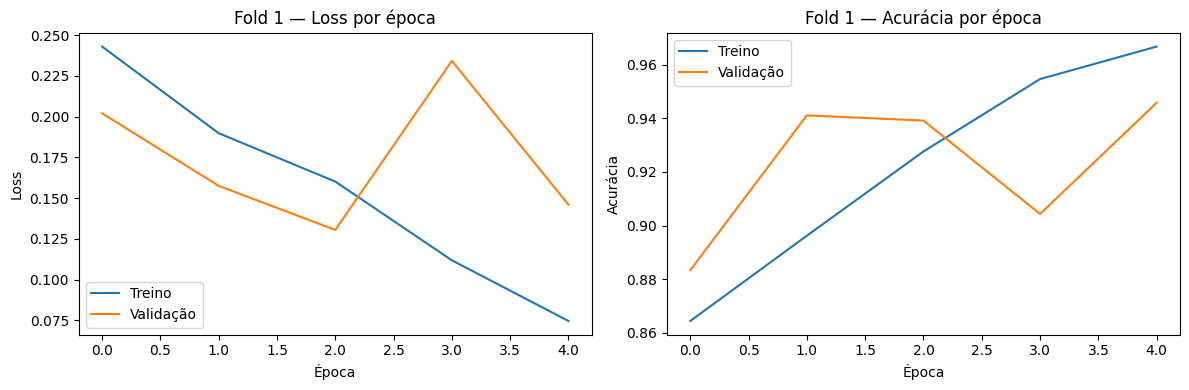


--- Fold 1 (melhor modelo, AUC=0.9871) ---
accuracy    : 0.9458
precision   : 0.8536
recall      : 0.9113
f1          : 0.8815
specificity : 0.9556
auc         : 0.9871


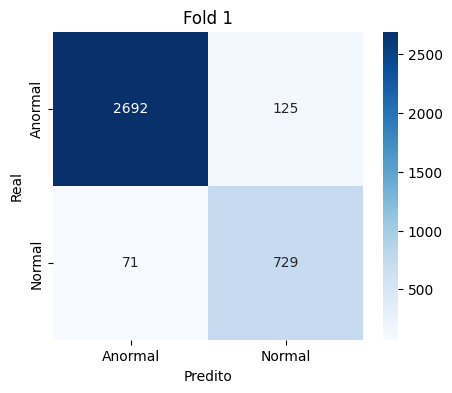


========== FOLD 2/3 ==========


/tmp/ipykernel_3005/1128469580.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Fold 2 - épocas:   0%|          | 0/5 [00:00<?, ?it/s]

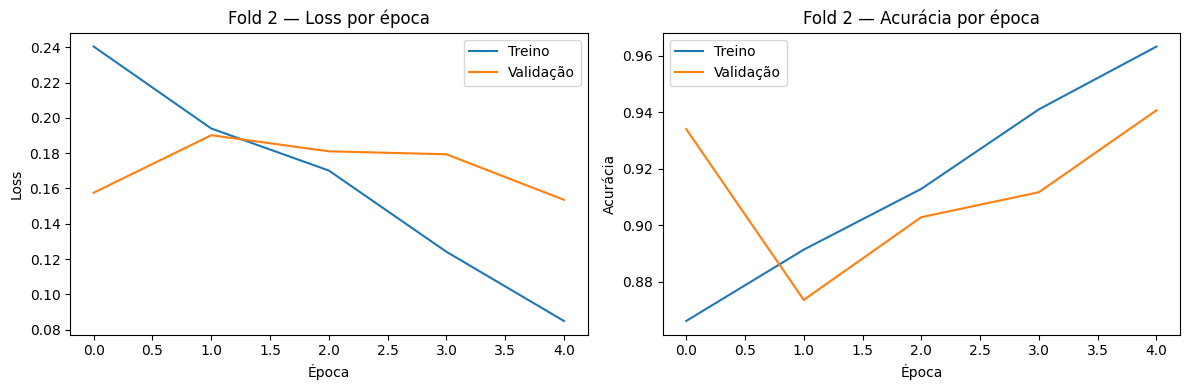


--- Fold 2 (melhor modelo, AUC=0.9839) ---
accuracy    : 0.9406
precision   : 0.8561
recall      : 0.8806
f1          : 0.8682
specificity : 0.9578
auc         : 0.9839


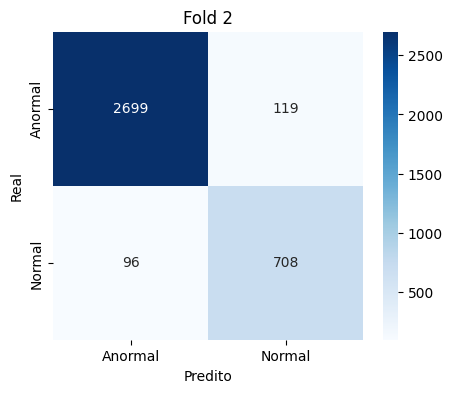


========== FOLD 3/3 ==========


/tmp/ipykernel_3005/1128469580.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Fold 3 - épocas:   0%|          | 0/5 [00:00<?, ?it/s]

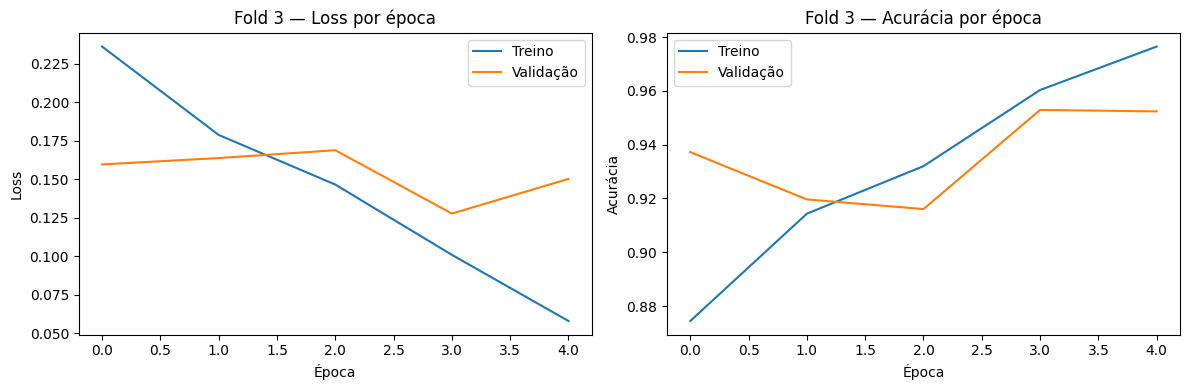


--- Fold 3 (melhor modelo, AUC=0.9865) ---
accuracy    : 0.9524
precision   : 0.8881
recall      : 0.8980
f1          : 0.8930
specificity : 0.9678
auc         : 0.9865


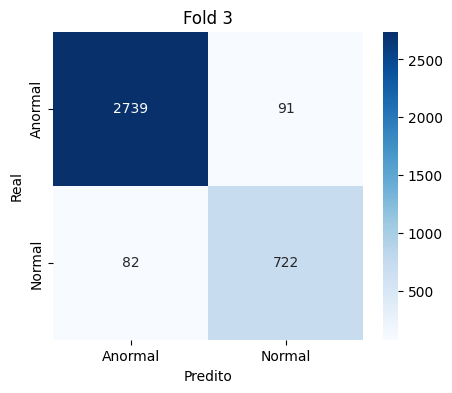


Tempo total: 86.2 min

MÉDIA FINAL (todos os folds)
accuracy    : 0.9463 ± 0.0048
precision   : 0.8659 ± 0.0157
recall      : 0.8966 ± 0.0126
f1          : 0.8809 ± 0.0101
specificity : 0.9604 ± 0.0053
auc         : 0.9858 ± 0.0014


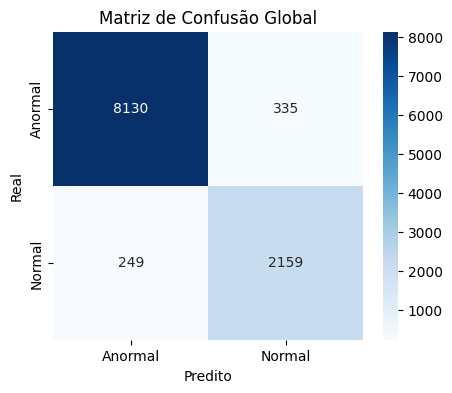


              precision    recall  f1-score   support

     Anormal       0.97      0.96      0.97      8465
      Normal       0.87      0.90      0.88      2408

    accuracy                           0.95     10873
   macro avg       0.92      0.93      0.92     10873
weighted avg       0.95      0.95      0.95     10873



In [11]:
metricas_por_fold = []
todas_labels, todas_preds = [], []
inicio_total = time.time()

for fold, (idx_treino, idx_val) in enumerate(skf.split(indices, targets, groups=grupos), 1):
    print(f"\n{'='*10} FOLD {fold}/{N_FOLDS} {'='*10}")

    sub_treino = torch.utils.data.Subset(dataset_cv, idx_treino)
    sub_treino.dataset.transform = train_transform
    loader_treino = DataLoader(sub_treino, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True,
                                persistent_workers=NUM_WORKERS > 0)

    sub_val = torch.utils.data.Subset(dataset_cv, idx_val)
    sub_val.dataset.transform = test_transform
    loader_val = DataLoader(sub_val, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True,
                             persistent_workers=NUM_WORKERS > 0)

    modelo, historico, melhor_auc = treinar_fold(fold, loader_treino, loader_val, targets[idx_treino])
    plotar_historico(historico, fold)

    y_true, y_pred, y_prob = avaliar_modelo(modelo, loader_val)
    metricas = calcular_metricas(y_true, y_pred, y_prob)
    imprimir_metricas(metricas, titulo=f"Fold {fold} (melhor modelo, AUC={melhor_auc:.4f})")
    plotar_matriz_confusao(metricas["confusion_matrix"], f"Fold {fold}")

    metricas_por_fold.append(metricas)
    todas_labels.extend(y_true)
    todas_preds.extend(y_pred)

    del modelo
    torch.cuda.empty_cache()

print(f"\nTempo total: {(time.time()-inicio_total)/60:.1f} min")

print("\n" + "="*50)
print("MÉDIA FINAL (todos os folds)")
print("="*50)
for chave in ["accuracy", "precision", "recall", "f1", "specificity", "auc"]:
    valores = [m[chave] for m in metricas_por_fold]
    print(f"{chave:12s}: {np.mean(valores):.4f} ± {np.std(valores):.4f}")

plotar_matriz_confusao(confusion_matrix(todas_labels, todas_preds), "Matriz de Confusão Global")
print("\n" + classification_report(todas_labels, todas_preds, target_names=NOMES_CLASSES))


## Resumo do modelo:

<pre style="font-family: monospace; line-height: 1.2; font-size: 12px; white-space: pre; overflow-x: auto; background-color: #0d1117; color: #c9d1d9; padding: 15px; border-radius: 6px;">
+-----------------------------------------------------------------------+
|                         1. ENTRADA DE DADOS                           |
|  • Imagens Mamográficas (Mini-DDSM JPEG)                              |
+-----------------------------------------------------------------------+
                                   |
                                   v
+-----------------------------------------------------------------------+
|                       2. PRÉ-PROCESSAMENTO                            |
|  • Recorte de Tecido (Remove fundo preto por contorno)                |
|  • Redimensionamento (224 x 224 px)                                   |
|  • CLAHE (Realce de contraste para microcalcificações/densidade)      |
|  • Conversão para RGB (3 canais) + Normalização ImageNet              |
+-----------------------------------------------------------------------+
                                   |
                                   v
+-----------------------------------------------------------------------+
|                    3. AUGMENTATION (Apenas Treino)                    |
|  • Random Crop (0.8 - 1.0) | Horizontal Flip | Random Rotation (15°) |
+-----------------------------------------------------------------------+
                                   |
                                   v
+-----------------------------------------------------------------------+
|               4. ESTRUTURA DO MODELO (Swin-Tiny)                      |
|                                                                       |
|  [ Patch Embedding ] ---------> (CONGELADO)                           |
|           |                                                           |
|  [ Stages 1 & 2 ] ------------> (CONGELADOS)                          |
|           |                                                           |
|  [ Stages 3 & 4 ] ------------> (TREINÁVEIS)                          |
|           |                                                           |
|  [ Cabeça de Classificação ] -> (TREINÁVEL - 2 saídas)                |
+-----------------------------------------------------------------------+
                                   |
                                   v
+-----------------------------------------------------------------------+
|                 5. TREINAMENTO E VALIDAÇÃO (5-Fold)                   |
|  • Agrupamento por Paciente (StratifiedGroupKFold - 5 splits)          |
|  • Loss: CrossEntropy com Pesos de Classe                             |
|  • Otimizador: AdamW (lr=1e-4) + Cosine Annealing Scheduler           |
|  • Monitoramento: Early Stopping (Paciência = 5 épocas via AUC)       |
+-----------------------------------------------------------------------+
                                   |
                                   v
+-----------------------------------------------------------------------+
|                         6. SAÍDA E MÉTRICAS                           |
|  • Predição: Normal vs. Anormal                                      |
|  • Avaliação: AUC-ROC, Acurácia, Sensibilidade, Especificidade, F1    |
+-----------------------------------------------------------------------+
</pre>